<a href="https://colab.research.google.com/github/BALJITrs7/GNN-IDS/blob/main/KNNGraph_Gatv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch-geometric -q

In [2]:
import os

import pandas as pd
import numpy as np

import torch

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from torch_geometric.data import Data

In [3]:
DATASET_DIR = "/Users/balji/OneDrive/GNN_IDS/Balanced_6Class_400K"

files = {
    "BENIGN.csv":0,
    "DDoS.csv":1,
    "DoS.csv":1,
    "Mirai.csv":1,
    "Recon.csv":1,
    "Spoofing.csv":1
}

dfs = []

for file,label in files.items():

    path = os.path.join(DATASET_DIR,file)

    df = pd.read_csv(path)

    attack_name = file.replace(".csv","")

    df["attack_type"] = attack_name

    df["label"] = label

    dfs.append(df)

data = pd.concat(
    dfs,
    ignore_index=True
)

print(data.shape)

print(data["attack_type"].value_counts())

(400000, 88)
attack_type
BENIGN      200000
DDoS         40000
DoS          40000
Mirai        40000
Recon        40000
Spoofing     40000
Name: count, dtype: int64


In [4]:
data = data.sort_values(
    "bidirectional_first_seen_ms"
).reset_index(drop=True)

data["flow_id"] = np.arange(len(data))

print(data.shape)

(400000, 89)


In [5]:
attack_type_backup = data["attack_type"].copy()

In [6]:
DROP_COLS = [

    "id",
    "expiration_id",

    "src_ip",
    "dst_ip",


   # "dst_port",
    #"src_port",
    #"protocol",
   # "ip_version"

    "src_mac",
    "dst_mac",

    "src_oui",
    "dst_oui",

    "requested_server_name",

    "client_fingerprint",
    "server_fingerprint",

    "user_agent",
    "content_type",

    "application_name",
    "application_category_name",

    "flow_id",
    "label",
    "attack_type",

    "bidirectional_first_seen_ms",
    "bidirectional_last_seen_ms",

    "src2dst_first_seen_ms",
    "src2dst_last_seen_ms",

    "dst2src_first_seen_ms",
    "dst2src_last_seen_ms",

    "application_confidence",
    "application_is_guessed",

    "vlan_id",
    "tunnel_id",

    "bidirectional_urg_packets",
    "src2dst_urg_packets",
    "dst2src_urg_packets",

    "dst2src_cwr_packets",
    "dst2src_ece_packets",

    "src_port",

    "bidirectional_duration_ms",
    "bidirectional_packets",

    "src2dst_packets",
    "dst2src_packets",

    "dst2src_min_ps",
    "dst2src_mean_ps",

    "bidirectional_min_piat_ms",
    "bidirectional_stddev_piat_ms",

    "dst2src_min_piat_ms",
    "dst2src_mean_piat_ms",
    "dst2src_max_piat_ms",

    "bidirectional_ece_packets",
    "bidirectional_psh_packets",
    "bidirectional_fin_packets",

    "src2dst_syn_packets",
    "src2dst_cwr_packets",
    "src2dst_ack_packets",
    "src2dst_rst_packets",
    "src2dst_fin_packets",

    "src2dst_mean_piat_ms",
    "src2dst_stddev_ps",

    "dst2src_ack_packets",
    "dst2src_psh_packets",
    "dst2src_rst_packets",
    "dst2src_fin_packets",

]

feature_cols = [

    c
    for c in data.columns
    if c not in DROP_COLS
]

print("Features:",len(feature_cols))

Features: 30


In [7]:
feature_cols = [
    c
    for c in data.columns
    if c not in DROP_COLS
]

print("Features:", len(feature_cols))

print("\nRetained Features:\n")
for i, f in enumerate(feature_cols, start=1):
    print(f"{i:2d}. {f}")

Features: 30

Retained Features:

 1. dst_port
 2. protocol
 3. ip_version
 4. bidirectional_bytes
 5. src2dst_duration_ms
 6. src2dst_bytes
 7. dst2src_duration_ms
 8. dst2src_bytes
 9. bidirectional_min_ps
10. bidirectional_mean_ps
11. bidirectional_stddev_ps
12. bidirectional_max_ps
13. src2dst_min_ps
14. src2dst_mean_ps
15. src2dst_max_ps
16. dst2src_stddev_ps
17. dst2src_max_ps
18. bidirectional_mean_piat_ms
19. bidirectional_max_piat_ms
20. src2dst_min_piat_ms
21. src2dst_stddev_piat_ms
22. src2dst_max_piat_ms
23. dst2src_stddev_piat_ms
24. bidirectional_syn_packets
25. bidirectional_cwr_packets
26. bidirectional_ack_packets
27. bidirectional_rst_packets
28. src2dst_ece_packets
29. src2dst_psh_packets
30. dst2src_syn_packets


In [8]:
top30 = {
    "bidirectional_mean_ps",
    "dst2src_syn_packets",
    "src2dst_min_ps",
    "ip_version",
    "src2dst_max_piat_ms",
    "dst2src_stddev_piat_ms",
    "bidirectional_max_piat_ms",
    "bidirectional_rst_packets",
    "src2dst_max_ps",
    "src2dst_duration_ms",
    "src2dst_bytes",
    "src2dst_ece_packets",
    "bidirectional_max_ps",
    "dst2src_bytes",
    "bidirectional_bytes",
    "dst2src_max_ps",
    "bidirectional_min_ps",
    "bidirectional_syn_packets",
    "dst2src_stddev_ps",
    "bidirectional_ack_packets",
    "protocol",
    "dst_port",
    "bidirectional_mean_piat_ms",
    "dst2src_duration_ms",
    "src2dst_mean_ps",
    "src2dst_min_piat_ms",
    "bidirectional_stddev_ps",
    "src2dst_stddev_piat_ms",
    "bidirectional_cwr_packets",
    "src2dst_psh_packets"
}

retained = set(feature_cols)

print("Missing from retained:")
print(sorted(top30 - retained))

print("\nExtra retained features:")
print(sorted(retained - top30))

Missing from retained:
[]

Extra retained features:
[]


In [9]:
for col in feature_cols:

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

data[feature_cols] = (
    data[feature_cols]
    .fillna(0)
)

In [10]:
scaler = StandardScaler()

X = scaler.fit_transform(
    data[feature_cols]
)

print(X.shape)


(400000, 30)


In [11]:
from sklearn.neighbors import NearestNeighbors
import torch

k = 5

nbrs = NearestNeighbors(
    n_neighbors=k + 1,
    algorithm='auto'
).fit(X)

distances, indices = nbrs.kneighbors(X)

edge_list = []

for i in range(len(X)):

    for j in indices[i][1:]:   # skip self

        edge_list.append([i, j])

edge_index = torch.tensor(
    edge_list,
    dtype=torch.long
).t().contiguous()

print(edge_index.shape)

torch.Size([2, 2000000])


In [12]:
flow_features = torch.tensor(
    X,
    dtype=torch.float
)

y = torch.tensor(
    data["label"].values,
    dtype=torch.long
)

In [13]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    np.arange(len(data)),
    test_size=0.2,
    stratify=data["label"],
    random_state=42
)

train_mask = torch.zeros(
    len(data),
    dtype=torch.bool
)

test_mask = torch.zeros(
    len(data),
    dtype=torch.bool
)

train_mask[train_idx] = True
test_mask[test_idx] = True

print("Train:", train_mask.sum())
print("Test :", test_mask.sum())

Train: tensor(320000)
Test : tensor(80000)


In [14]:
from torch_geometric.data import Data

graph = Data(
    x=flow_features,
    edge_index=edge_index,
    y=y,
    train_mask=train_mask,
    test_mask=test_mask
)

print(graph)

Data(x=[400000, 30], edge_index=[2, 2000000], y=[400000], train_mask=[400000], test_mask=[400000])


In [16]:
from torch_geometric.loader import NeighborLoader

train_loader = NeighborLoader(
    graph,
    num_neighbors=[15,10],
    batch_size=2048,
    input_nodes=graph.train_mask,
    shuffle=True
)

test_loader = NeighborLoader(
    graph,
    num_neighbors=[15,10],
    batch_size=2048,
    input_nodes=graph.test_mask,
    shuffle=False
)

print(
    f"Train batches: {len(train_loader)}"
)

Train batches: 157


In [17]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv

class GATModel(torch.nn.Module):
    def __init__(
        self,
        in_channels,
        hidden_channels,
        num_classes,
        heads=4
    ):
        super().__init__()

        # Layer 1
        self.conv1 = GATv2Conv(
            in_channels,
            hidden_channels // heads,
            heads=heads
        )

        # Layer 2
        self.conv2 = GATv2Conv(
            hidden_channels,
            hidden_channels // heads,
            heads=heads
        )

        # Layer 3: Output matches hidden_channels // 2 (128)
        self.conv3 = GATv2Conv(
            hidden_channels,
            (hidden_channels // 2) // heads,
            heads=heads
        )

        self.bn1 = torch.nn.BatchNorm1d(hidden_channels)
        self.bn2 = torch.nn.BatchNorm1d(hidden_channels)
        self.bn3 = torch.nn.BatchNorm1d(hidden_channels // 2)

        self.classifier = torch.nn.Linear(
            hidden_channels // 2,
            num_classes
        )

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.4, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.4, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        x = self.classifier(x)

        return x

In [18]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [19]:
model = GATModel(
    in_channels=graph.num_node_features,
    hidden_channels=256,
    num_classes=2,
    heads=4
)

model = model.to(device)
graph = graph.to(device)

print(model)

GATModel(
  (conv1): GATv2Conv(30, 64, heads=4)
  (conv2): GATv2Conv(256, 64, heads=4)
  (conv3): GATv2Conv(256, 32, heads=4)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (classifier): Linear(in_features=128, out_features=2, bias=True)
)


In [20]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.002,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=20,
    gamma=0.5
)

In [21]:
weights = torch.tensor(
    [1.0, 2.0],
    dtype=torch.float
).to(device)

criterion = torch.nn.CrossEntropyLoss(
    weight=weights
)

In [22]:
def train_epoch():
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        # Forward pass on the subgraph
        out = model(batch.x, batch.edge_index)

        # SLICE: Calculate loss strictly for the seed nodes
        loss = criterion(out[:batch.batch_size], batch.y[:batch.batch_size])

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.batch_size

    return total_loss / graph.train_mask.sum().item()

@torch.no_grad()
def evaluate_epoch(loader, mask_size):
    model.eval()
    correct = 0

    for batch in loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index)

        # Evaluate strictly for the seed nodes
        pred = out[:batch.batch_size].argmax(dim=1)
        y_true = batch.y[:batch.batch_size]

        correct += (pred == y_true).sum().item()

    return correct / mask_size



In [23]:
# Training Execution
for epoch in range(1, 51):
    loss = train_epoch()
    train_acc = evaluate_epoch(train_loader, graph.train_mask.sum().item())
    test_acc = evaluate_epoch(test_loader, graph.test_mask.sum().item())

    scheduler.step()

    print(f"Epoch {epoch:02d} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

Epoch 01 | Loss: 0.4156 | Train Acc: 0.6615 | Test Acc: 0.6601
Epoch 02 | Loss: 0.3744 | Train Acc: 0.7075 | Test Acc: 0.7071
Epoch 03 | Loss: 0.3615 | Train Acc: 0.8311 | Test Acc: 0.8307
Epoch 04 | Loss: 0.3525 | Train Acc: 0.8283 | Test Acc: 0.8277
Epoch 05 | Loss: 0.3443 | Train Acc: 0.8391 | Test Acc: 0.8406
Epoch 06 | Loss: 0.3385 | Train Acc: 0.8478 | Test Acc: 0.8488
Epoch 07 | Loss: 0.3289 | Train Acc: 0.8270 | Test Acc: 0.8281
Epoch 08 | Loss: 0.3227 | Train Acc: 0.8580 | Test Acc: 0.8589
Epoch 09 | Loss: 0.3155 | Train Acc: 0.8291 | Test Acc: 0.8295
Epoch 10 | Loss: 0.3133 | Train Acc: 0.8479 | Test Acc: 0.8486
Epoch 11 | Loss: 0.3086 | Train Acc: 0.8466 | Test Acc: 0.8485
Epoch 12 | Loss: 0.3021 | Train Acc: 0.8504 | Test Acc: 0.8525
Epoch 13 | Loss: 0.2990 | Train Acc: 0.8373 | Test Acc: 0.8392
Epoch 14 | Loss: 0.2964 | Train Acc: 0.8757 | Test Acc: 0.8781
Epoch 15 | Loss: 0.2941 | Train Acc: 0.8378 | Test Acc: 0.8394
Epoch 16 | Loss: 0.2935 | Train Acc: 0.8517 | Test Acc:

In [24]:
model.eval()
all_preds = []

print("Gathering blind test set predictions via subgraphs...")

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index)

        # Apply Softmax strictly to the seed nodes
        probs = torch.softmax(out[:batch.batch_size], dim=1)
        attack_prob = probs[:, 1]

        # Maintain your adjusted 0.35 threshold logic
        batch_pred = (attack_prob > 0.5).long()
        all_preds.extend(batch_pred.cpu().numpy())

# Convert the final list back to a tensor so Cell 29 runs seamlessly
pred = torch.tensor(all_preds)
print("Predictions successfully gathered!")

Gathering blind test set predictions via subgraphs...
Predictions successfully gathered!


In [25]:
from sklearn.metrics import (
    classification_report
)

y_true = graph.y[graph.test_mask].cpu().numpy()
y_pred = pred.cpu().numpy()

test_rows = data.iloc[test_idx].reset_index(drop=True)

test_rows["pred"] = y_pred

print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.91      0.76      0.82     40000
           1       0.79      0.92      0.85     40000

    accuracy                           0.84     80000
   macro avg       0.85      0.84      0.84     80000
weighted avg       0.85      0.84      0.84     80000



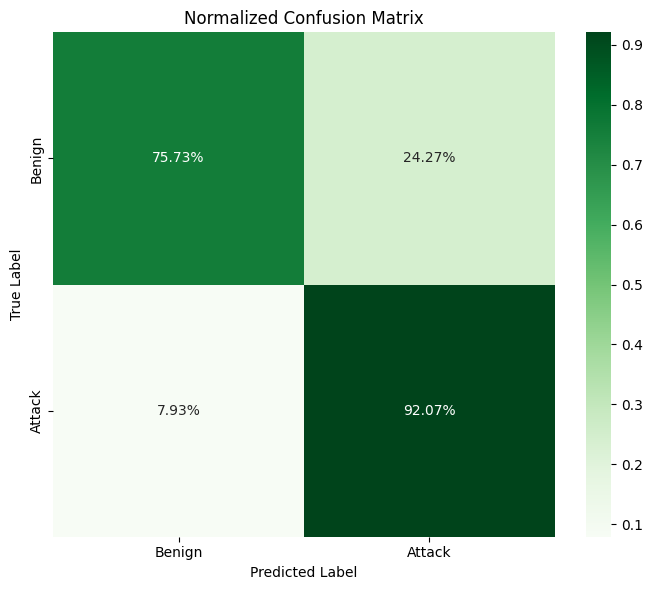

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# True labels
#y_true = graph.y[graph.test_mask].cpu().numpy()

# Predicted labels
#y_pred = pred[graph.test_mask].cpu().numpy()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalize row-wise
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2%",
    cmap="Greens",
    xticklabels=["Benign", "Attack"],
    yticklabels=["Benign", "Attack"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
recon_rows = test_rows[
    test_rows["attack_type"] == "Recon"
]

recon_rows["pred"] = pd.Series(y_pred)

print(
    recon_rows["pred"]
    .value_counts()
)

In [ ]:
recon_fn = recon_rows[
    recon_rows["pred"] == 0
]

print(recon_fn.head())

In [ ]:
recon_fn = recon_rows[
    recon_rows["pred"] == 0
]

print(
    recon_fn["src_ip"]
    .value_counts()
    .head(20)
)

In [ ]:
print(
    recon_rows["src_ip"]
    .nunique()
)

print(
    recon_fn["src_ip"]
    .nunique()
)

In [ ]:
host = "192.168.137.41"

host_recon = recon_rows[
    recon_rows["src_ip"] == host
]

print(len(host_recon))

print(
    host_recon["pred"]
    .value_counts()
)

In [ ]:
host = "192.168.137.41"

print(
    data[
        data["src_ip"] == host
    ]["attack_type"]
    .value_counts()
)

In [ ]:
for host in [
    "192.168.137.41",
    "192.168.137.133",
    "192.168.137.1"
]:
    print("\n", host)
    print(
        data[data["src_ip"] == host]["attack_type"]
        .value_counts()
    )

In [ ]:
host = "192.168.137.1"

host_test = test_rows[
    test_rows["src_ip"] == host
]

print(
    host_test.groupby("attack_type")["pred"]
    .mean()
    .sort_values()
)

In [ ]:
host = "192.168.137.41"

host_test = test_rows[
    test_rows["src_ip"] == host
]

print(
    host_test.groupby("attack_type")["pred"]
    .mean()
    .sort_values()
)